Eğitim Setindeki Sağlıklı (Normal) Röntgen Sayısı: 1341
Eğitim Setindeki Zatürre (Pneumonia) Röntgen Sayısı: 3875
--------------------------------------------------


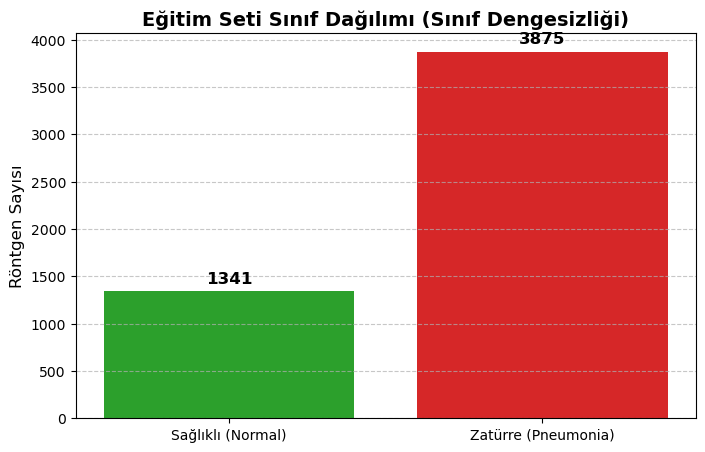

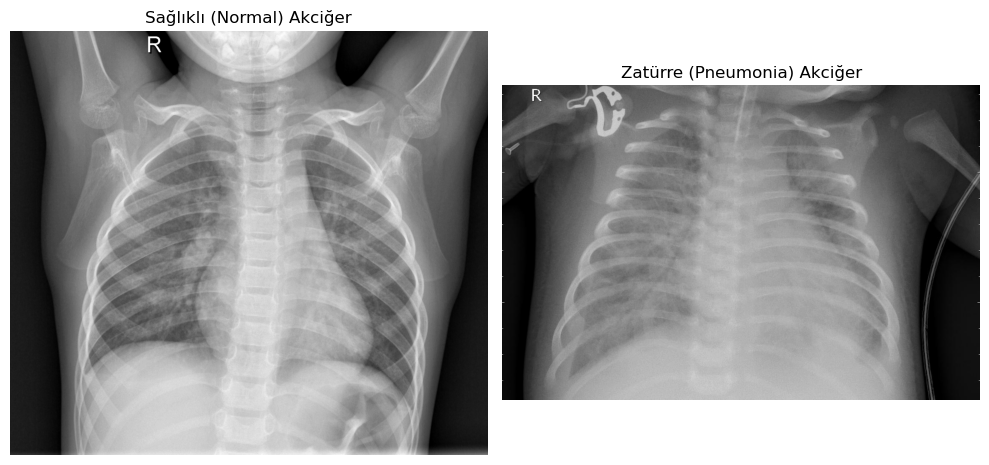

In [3]:
# =====================================================================
# BÖLÜM 1: KÜTÜPHANELERİN YÜKLENMESİ VE VERİ YOLLARININ BELİRLENMESİ
# =====================================================================

# os: İşletim sistemiyle iletişim kurmamızı ve klasörlerde gezinmemizi sağlar.
import os 

# pyplot: Ekrana grafik ve resim çizdirmek (tuval açmak) için kullanılır.
import matplotlib.pyplot as plt 

# mpimg: Bilgisayardaki resim dosyasını okuyup sayısal (piksel) matrislere çevirir.
import matplotlib.image as mpimg 

# os.path.join(): Klasör yollarını (işletim sistemine uygun şekilde) hatasız birleştirir.
train_dir = '../data/train'
normal_dir = os.path.join(train_dir, 'NORMAL')
pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')


# =====================================================================
# BÖLÜM 2: VERİ SAYILARININ HESAPLANMASI VE EKRANA YAZDIRILMASI
# =====================================================================

# os.listdir(): Belirtilen klasörün içindeki tüm resim dosyalarının isimlerini bir liste olarak getirir.
# len(): Bu listenin uzunluğunu sayar. Sınıf dengesizliğini (imbalance) görmek için bunu kullanıyoruz.
normal_sayisi = len(os.listdir(normal_dir))
zaturre_sayisi = len(os.listdir(pneumonia_dir))

print(f"Eğitim Setindeki Sağlıklı (Normal) Röntgen Sayısı: {normal_sayisi}")
print(f"Eğitim Setindeki Zatürre (Pneumonia) Röntgen Sayısı: {zaturre_sayisi}")
print("-" * 50)


# =====================================================================
# BÖLÜM 3: SINIF DAĞILIMININ ÇUBUK GRAFİĞİ İLE GÖRSELLEŞTİRİLMESİ
# =====================================================================

# X eksenindeki sınıf isimleri ve Y eksenindeki sayılar (1341 ve 3875)
siniflar = ['Sağlıklı (Normal)', 'Zatürre (Pneumonia)']
sayilar = [normal_sayisi, zaturre_sayisi]

# 8x5 inç boyutunda bir grafik alanı (tuval) açıyoruz
plt.figure(figsize=(8, 5))

# Çubuk grafiğini çizdiriyoruz (Sağlıklı: Yeşil, Zatürre: Kırmızı)
bars = plt.bar(siniflar, sayilar, color=['#2ca02c', '#d62728'])

# Çubukların tam tepesine sayıları okunaklı bir şekilde yazdırıyoruz
for bar in bars:
    y_degeri = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y_degeri + 50, int(y_degeri), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Grafiği rapor için isimlendiriyoruz
plt.title('Eğitim Seti Sınıf Dağılımı (Sınıf Dengesizliği)', fontsize=14, fontweight='bold')
plt.ylabel('Röntgen Sayısı', fontsize=12)

# Arka plana okunabilirliği artıran yatay kesik çizgiler ekliyoruz
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# =====================================================================
# BÖLÜM 4: ÖRNEK RÖNTGEN GÖRÜNTÜLERİNİN EKRANA ÇİZDİRİLMESİ
# =====================================================================

# listdir()[0]: Klasördeki resim listesinin ilk elemanını (0. indeks) yani ilk resmi seçeriz.
normal_ilk_resim = os.listdir(normal_dir)[0]
zaturre_ilk_resim = os.listdir(pneumonia_dir)[0]

# mpimg.imread(): Seçilen resmi okur ve bilgisayarın anlayacağı 0-255 arası piksel değerlerinden oluşan bir matrise dönüştürür.
img_normal = mpimg.imread(os.path.join(normal_dir, normal_ilk_resim))
img_zaturre = mpimg.imread(os.path.join(pneumonia_dir, zaturre_ilk_resim))

# plt.subplots(1, 2): 1 satır ve 2 sütundan oluşan, yan yana duran iki adet boş grafik alanı (tuval) açar.
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# imshow(): imread ile elde edilen piksel matrisini tekrar görsele çevirip ekrana basar.
# cmap='gray': Resmin siyah-beyaz (röntgen formatında) çizdirilmesini sağlar ki model sadece yapıya odaklansın.
axes[0].imshow(img_normal, cmap='gray')
axes[0].set_title('Sağlıklı (Normal) Akciğer')

# axis('off'): Resmin etrafındaki X ve Y eksenindeki sayıları (koordinatları) gizler, temiz görüntü sağlar.
axes[0].axis('off') 

axes[1].imshow(img_zaturre, cmap='gray')
axes[1].set_title('Zatürre (Pneumonia) Akciğer')
axes[1].axis('off')

# plt.tight_layout(): İki resmin başlıklarının ve çerçevelerinin birbirine girmesini engeller.
plt.tight_layout()

# plt.show(): Hazırlanan tüm grafikleri kullanıcıya (ekrana) yansıtır.
plt.show()

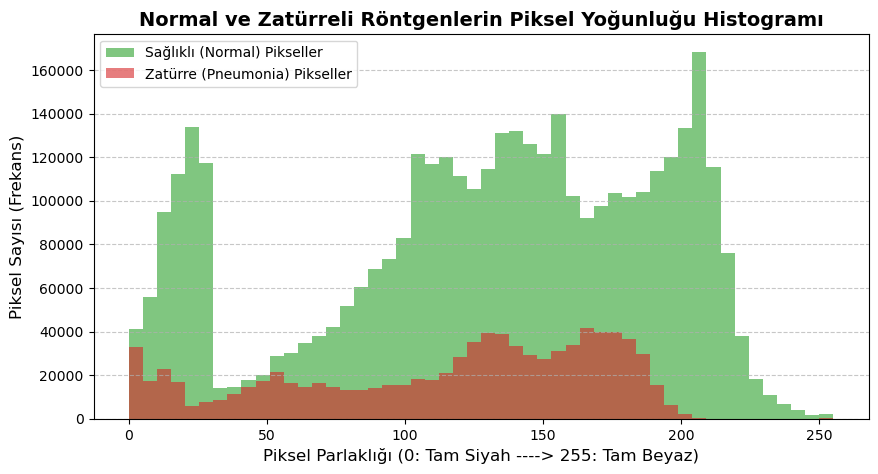

In [4]:
# ---------------------------------------------------------
# ADIM 5: PİKSEL YOĞUNLUĞU HİSTOGRAMI (Histogram Analysis)
# ---------------------------------------------------------
import numpy as np

# Önceki hücrelerde okuduğumuz img_normal ve img_zaturre matrislerini kullanıyoruz.
# Resimler 2 boyutlu (X, Y) olduğu için, pikselleri sayabilmek adına ravel() ile tek boyutlu bir listeye (1D) düzleştiriyoruz.
pixels_normal = img_normal.ravel()
pixels_zaturre = img_zaturre.ravel()

# Yeni bir grafik alanı açıyoruz
plt.figure(figsize=(10, 5))

# Sağlıklı resmin piksellerini yeşil, zatürreli resmin piksellerini kırmızı çizdiriyoruz.
# bins=50: Pikselleri 50 farklı ton grubuna ayırır. alpha=0.6: Grafikleri şeffaflaştırarak kesişimleri gösterir.
plt.hist(pixels_normal, bins=50, alpha=0.6, color='#2ca02c', label='Sağlıklı (Normal) Pikseller')
plt.hist(pixels_zaturre, bins=50, alpha=0.6, color='#d62728', label='Zatürre (Pneumonia) Pikseller')

# Grafiği rapor için isimlendiriyoruz
plt.title('Normal ve Zatürreli Röntgenlerin Piksel Yoğunluğu Histogramı', fontsize=14, fontweight='bold')
plt.xlabel('Piksel Parlaklığı (0: Tam Siyah ----> 255: Tam Beyaz)', fontsize=12)
plt.ylabel('Piksel Sayısı (Frekans)', fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 1. Keşfedici Veri Analizi (EDA) ve Veri Setinin İncelenmesi

Projenin bu ilk aşamasında, *Chest X-Ray Images (Pneumonia)* veri setimizin eğitim (train) dizini incelenmiştir. Yapılan işlemler ve elde edilen bulgular aşağıda özetlenmiştir:

**1. İstatistiksel Dağılım ve Sınıf Dengesizliği:**
Yazılan kodlar sonucunda eğitim setindeki sınıf dağılımı şu şekilde hesaplanmıştır:
*   **Sağlıklı (Normal) Akciğer:** 1.341 adet görüntü
*   **Zatürre (Pneumonia) Akciğer:** 3.875 adet görüntü

Oluşturulan çubuk grafiğinde de net bir şekilde görüldüğü üzere, veri setinde yaklaşık 1:3 oranında ciddi bir **sınıf dengesizliği (class imbalance)** mevcuttur. Bu matematiksel tablo, modelin eğitim sırasında çoğunluk sınıfına (Zatürre) doğru bir yanlılık (bias) geliştirmesi riskini ortaya koymaktadır.

**2. Görsel İnceleme ve Piksel Yoğunluğu Histogramı:**
Ekrana çizdirilen örnek röntgenler ve piksel yoğunluğu histogramı incelendiğinde hastalığın karakteristik farkları tespit edilmiştir:
*   **Örnek Röntgenler:** Sağlıklı akciğerde hava boşlukları karanlıkken, zatürreli akciğerde enfeksiyon ve sıvı birikimi olan bölgeler bulutumsu, beyaz lekeler (opasite) şeklinde görünmektedir. 
*   **Histogram Kanıtı:** Çizdirilen piksel yoğunluğu histogramı bu görsel gözlemi matematiksel olarak ispatlamaktadır. Sağlıklı görüntülere ait pikseller (yeşil), grafiğin sol tarafındaki karanlık tonlarda toplanırken; zatürreli görüntülere ait pikseller (kırmızı), grafiğin sağ tarafına yani parlak beyaz tonlara doğru belirgin bir kayma göstermiştir. Kurulacak modelin ana öznitelik (feature) ayrımı bu parlaklık farkı olacaktır.